<a href="https://colab.research.google.com/github/Piyush-47928/DEEP-LEARNING/blob/main/LLE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
!pip install scikit-learn opencv-python

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from google.colab import files
from sklearn.metrics import accuracy_score, confusion_matrix

In [38]:
print("📤 Upload dataset ZIP file")
uploaded = files.upload()

import zipfile

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("✅ Dataset extracted successfully")

📤 Upload dataset ZIP file


Saving Faces.zip to Faces (2).zip
✅ Dataset extracted successfully


In [39]:
IMG_SIZE = 64

def load_images(dataset_path):
    X = []
    y = []

    for person_name in os.listdir(dataset_path):
        person_folder = os.path.join(dataset_path, person_name)
        if not os.path.isdir(person_folder):
            continue

        for img_name in os.listdir(person_folder):
            img_path = os.path.join(person_folder, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img.flatten()

            X.append(img)
            y.append(person_name)

    return np.array(X), np.array(y)

In [40]:
X, y = load_images("dataset")
print("Images loaded:", X.shape)

Images loaded: (2562, 4096)


In [41]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 2049
Testing samples: 513


In [43]:
lle = LocallyLinearEmbedding(
    n_neighbors=10,
    n_components=50,
    method='standard'
)

X_train_lle = lle.fit_transform(X_train)
X_test_lle = lle.transform(X_test)

print("LLE applied successfully")

LLE applied successfully


In [47]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_lle, y_train)

print("✅ Model trained using LLE embeddings")

✅ Model trained using LLE embeddings


In [50]:
y_pred = knn.predict(X_test_lle)
accuracy = accuracy_score(y_test, y_pred)

print("🎯 Test Accuracy:", accuracy)

🎯 Test Accuracy: 1.0


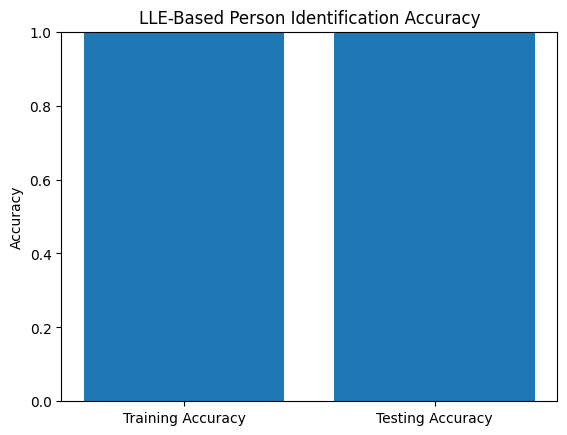

In [51]:
train_acc = knn.score(X_train_lle, y_train)
test_acc = accuracy

plt.figure()
plt.bar(["Training Accuracy", "Testing Accuracy"], [train_acc, test_acc])
plt.title("LLE-Based Person Identification Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


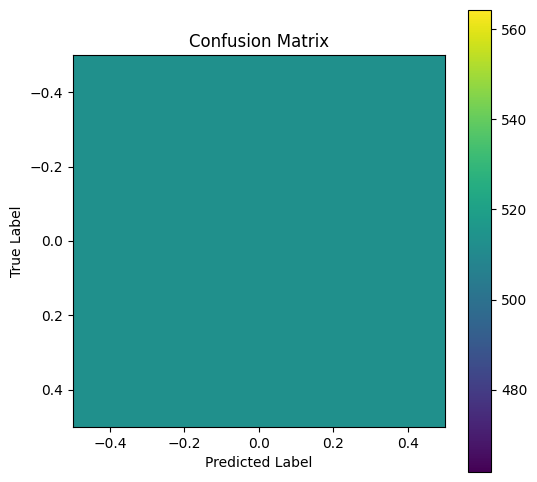

In [54]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [55]:
X_10 = X[:10]
y_10 = y_encoded[:10]

In [56]:
from sklearn.manifold import LocallyLinearEmbedding

lle_2d = LocallyLinearEmbedding(
    n_neighbors=5,
    n_components=2,
    method='standard'
)

X_10_lle = lle_2d.fit_transform(X_10)

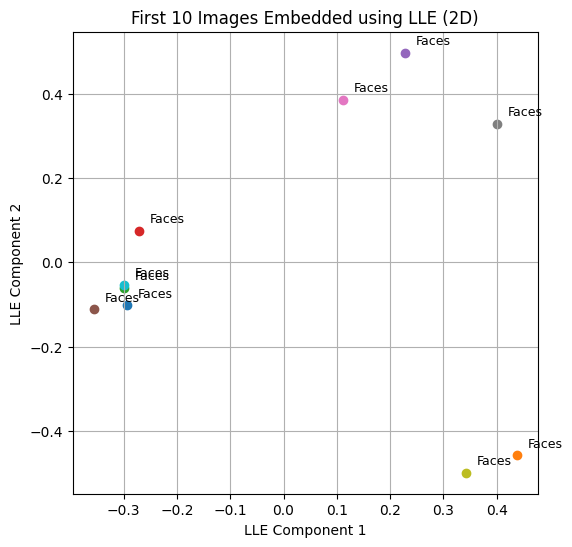

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

for i in range(10):
    plt.scatter(
        X_10_lle[i, 0],
        X_10_lle[i, 1]
    )
    plt.text(
        X_10_lle[i, 0] + 0.02,
        X_10_lle[i, 1] + 0.02,
        le.inverse_transform([y_10[i]])[0],
        fontsize=9
    )

plt.title("First 10 Images Embedded using LLE (2D)")
plt.xlabel("LLE Component 1")
plt.ylabel("LLE Component 2")
plt.grid(True)
plt.show()

In [58]:
IMG_SIZE = 64

X_10 = X[:10]
y_10 = y_encoded[:10]

images_10 = X_10.reshape(-1, IMG_SIZE, IMG_SIZE)

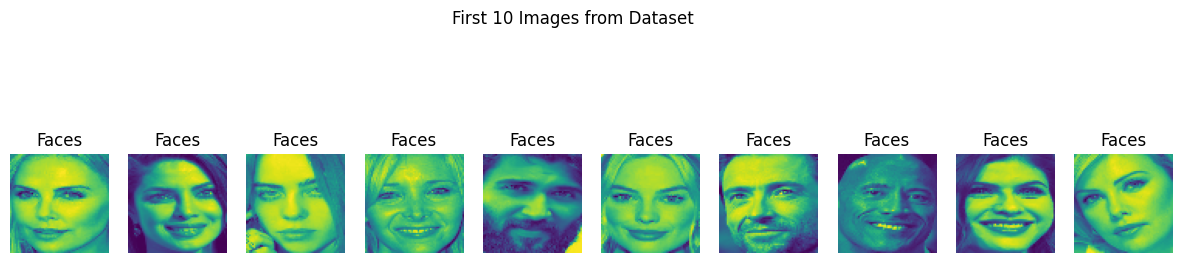

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(images_10[i])
    plt.title(le.inverse_transform([y_10[i]])[0])
    plt.axis("off")

plt.suptitle("First 10 Images from Dataset")
plt.show()

In [62]:
from sklearn.manifold import LocallyLinearEmbedding

lle_2d = LocallyLinearEmbedding(
    n_neighbors=5,
    n_components=2
)

X_10_lle = lle_2d.fit_transform(X_10)

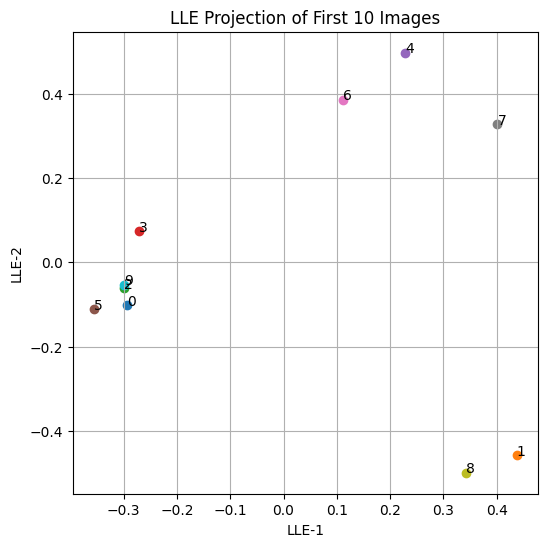

In [63]:
plt.figure(figsize=(6,6))

for i in range(10):
    plt.scatter(X_10_lle[i, 0], X_10_lle[i, 1])
    plt.text(
        X_10_lle[i, 0],
        X_10_lle[i, 1],
        str(i),
        fontsize=10
    )

plt.title("LLE Projection of First 10 Images")
plt.xlabel("LLE-1")
plt.ylabel("LLE-2")
plt.grid(True)
plt.show()